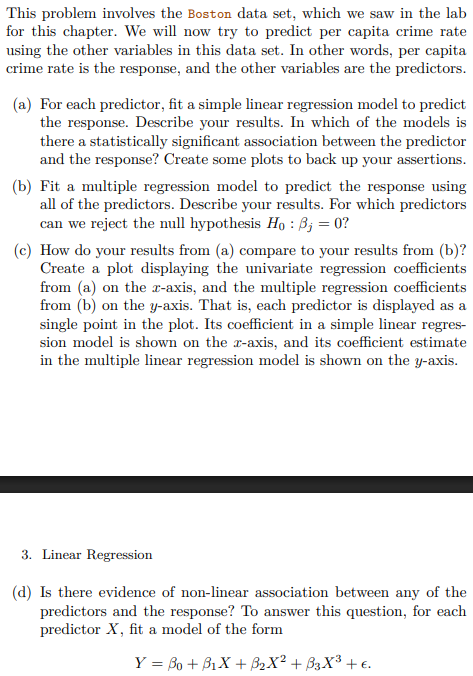


In [18]:
# Upload Boston dataset
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import io

print("Please upload the Boston dataset file (CSV format)")
uploaded = files.upload()

# Load the dataset
filename = list(uploaded.keys())[0]
boston = pd.read_csv(filename)

# Display basic information about the dataset
print("Dataset shape:", boston.shape)
print("\nFirst few rows:")
print(boston.head())
print("\nDataset info:")
print(boston.info())

Please upload the Boston dataset file (CSV format)


Saving boston_housing_transformed.csv to boston_housing_transformed (3).csv
Dataset shape: (506, 14)

First few rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506

In [19]:
# Verify column names and prepare for analysis
print("Column names in the dataset:")
print(boston.columns.tolist())

# Set response variable and predictors
response_var = 'CRIM'  # per capita crime rate
predictors = ['ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

print(f"\nResponse variable: {response_var}")
print(f"Predictors ({len(predictors)}): {predictors}")

# Basic statistics
print(f"\nBasic statistics for {response_var}:")
print(boston[response_var].describe())

Column names in the dataset:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Response variable: CRIM
Predictors (13): ['ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Basic statistics for CRIM:
count    506.000000
mean       3.613524
std        8.601545
min        0.006320
25%        0.082045
50%        0.256510
75%        3.677083
max       88.976200
Name: CRIM, dtype: float64


PART (a): SIMPLE LINEAR REGRESSION FOR EACH PREDICTOR


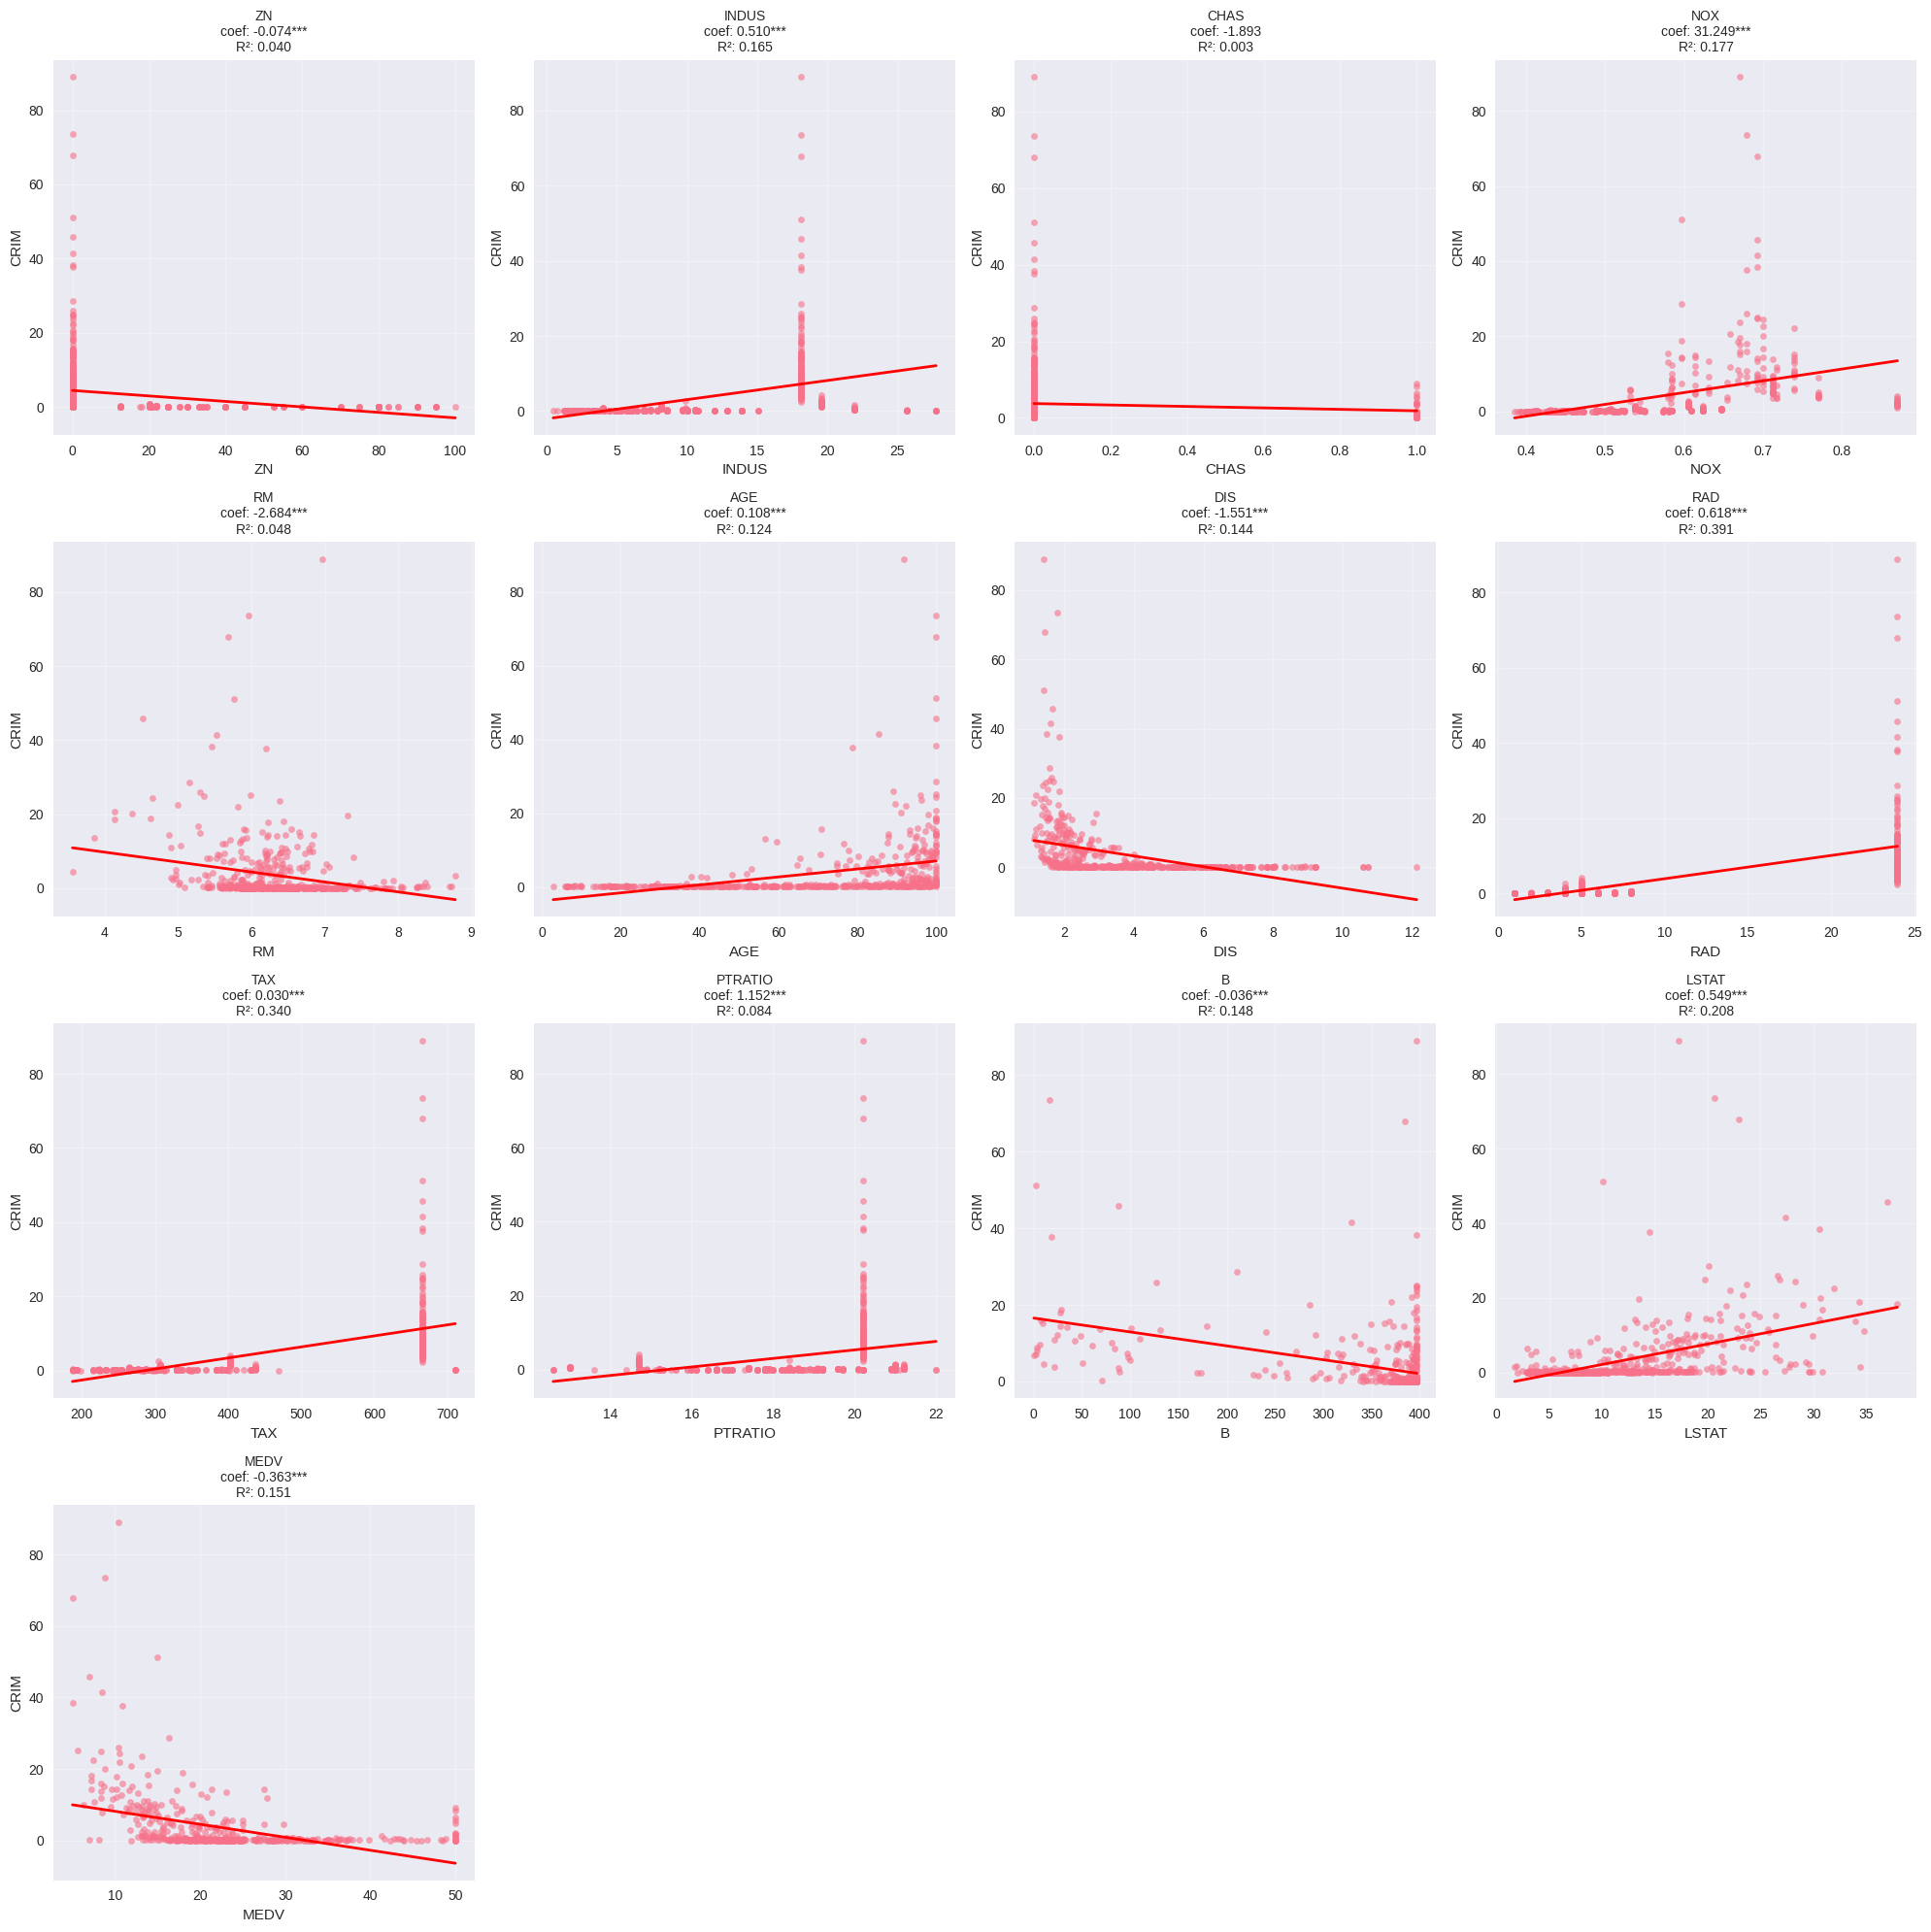


STATISTICALLY SIGNIFICANT PREDICTORS (p < 0.05):
----------------------------------------------------------------------
Predictor  Coefficient  P-value    R-squared  Significance   
----------------------------------------------------------------------
ZN            -0.0739    0.0000    0.0402 p < 0.001      
INDUS          0.5098    0.0000    0.1653 p < 0.001      
NOX           31.2485    0.0000    0.1772 p < 0.001      
RM            -2.6841    0.0000    0.0481 p < 0.001      
AGE            0.1078    0.0000    0.1244 p < 0.001      
DIS           -1.5509    0.0000    0.1441 p < 0.001      
RAD            0.6179    0.0000    0.3913 p < 0.001      
TAX            0.0297    0.0000    0.3396 p < 0.001      
PTRATIO        1.1520    0.0000    0.0841 p < 0.001      
B             -0.0363    0.0000    0.1483 p < 0.001      
LSTAT          0.5488    0.0000    0.2076 p < 0.001      
MEDV          -0.3632    0.0000    0.1508 p < 0.001      

Total significant predictors: 12 out of 13
Signif

In [20]:
# Part (a): Simple linear regression for each predictor
print("PART (a): SIMPLE LINEAR REGRESSION FOR EACH PREDICTOR")
print("=" * 70)

# Store results for each predictor
simple_reg_results = {}

# Create subplots for visualization
n_predictors = len(predictors)
n_cols = 4
n_rows = (n_predictors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    # Fit simple linear regression
    X = sm.add_constant(boston[predictor])
    y = boston[response_var]
    model = sm.OLS(y, X).fit()

    # Store results
    simple_reg_results[predictor] = {
        'coefficient': model.params[predictor],
        'p_value': model.pvalues[predictor],
        'r_squared': model.rsquared,
        'model': model
    }

    # Create scatter plot with regression line
    ax = axes[i]
    ax.scatter(boston[predictor], boston[response_var], alpha=0.6, s=20)

    # Plot regression line
    x_range = np.linspace(boston[predictor].min(), boston[predictor].max(), 100)
    X_pred = sm.add_constant(x_range)
    y_pred = model.predict(X_pred)
    ax.plot(x_range, y_pred, color='red', linewidth=2)

    # Add statistics to plot
    sig_star = "***" if model.pvalues[predictor] < 0.001 else "**" if model.pvalues[predictor] < 0.01 else "*" if model.pvalues[predictor] < 0.05 else ""
    ax.set_title(f'{predictor}\ncoef: {model.params[predictor]:.3f}{sig_star}\nR²: {model.rsquared:.3f}', fontsize=10)
    ax.set_xlabel(predictor)
    ax.set_ylabel(response_var)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Summary of significant predictors
print("\nSTATISTICALLY SIGNIFICANT PREDICTORS (p < 0.05):")
print("-" * 70)
print(f"{'Predictor':<10} {'Coefficient':<12} {'P-value':<10} {'R-squared':<10} {'Significance':<15}")
print("-" * 70)

significant_predictors = []
for predictor, results in simple_reg_results.items():
    if results['p_value'] < 0.05:
        significant_predictors.append(predictor)
        sig_level = "p < 0.001" if results['p_value'] < 0.001 else "p < 0.01" if results['p_value'] < 0.01 else "p < 0.05"
        print(f"{predictor:<10} {results['coefficient']:>10.4f} {results['p_value']:>9.4f} {results['r_squared']:>9.4f} {sig_level:<15}")

print(f"\nTotal significant predictors: {len(significant_predictors)} out of {len(predictors)}")
print(f"Significant predictors: {significant_predictors}")

In [21]:
# Part (b): Multiple regression with all predictors
print("\nPART (b): MULTIPLE REGRESSION WITH ALL PREDICTORS")
print("=" * 70)

# Prepare data for multiple regression
X_multiple = sm.add_constant(boston[predictors])
y = boston[response_var]

# Fit multiple regression model
multiple_model = sm.OLS(y, X_multiple).fit()

# Print full results
print(multiple_model.summary())

# Extract significant predictors from multiple regression
print("\nSIGNIFICANT PREDICTORS IN MULTIPLE REGRESSION (p < 0.05):")
print("-" * 70)
print(f"{'Predictor':<10} {'Coefficient':<12} {'P-value':<10} {'Significance':<15}")
print("-" * 70)

significant_multiple = []
for predictor in predictors:
    p_val = multiple_model.pvalues[predictor]
    if p_val < 0.05:
        significant_multiple.append(predictor)
        sig_level = "p < 0.001" if p_val < 0.001 else "p < 0.01" if p_val < 0.01 else "p < 0.05"
        coef = multiple_model.params[predictor]
        print(f"{predictor:<10} {coef:>10.4f} {p_val:>9.4f} {sig_level:<15}")

print(f"\nTotal significant predictors in multiple regression: {len(significant_multiple)} out of {len(predictors)}")
print(f"Significant predictors: {significant_multiple}")

# Compare model performance
print(f"\nMODEL PERFORMANCE COMPARISON:")
print(f"R-squared: {multiple_model.rsquared:.4f}")
print(f"Adjusted R-squared: {multiple_model.rsquared_adj:.4f}")
print(f"F-statistic: {multiple_model.fvalue:.4f}")
print(f"F-test p-value: {multiple_model.f_pvalue:.10f}")


PART (b): MULTIPLE REGRESSION WITH ALL PREDICTORS
                            OLS Regression Results                            
Dep. Variable:                   CRIM   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     31.47
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           1.57e-56
Time:                        02:21:35   Log-Likelihood:                -1653.3
No. Observations:                 506   AIC:                             3335.
Df Residuals:                     492   BIC:                             3394.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c


PART (c): COMPARISON OF SIMPLE VS MULTIPLE REGRESSION COEFFICIENTS


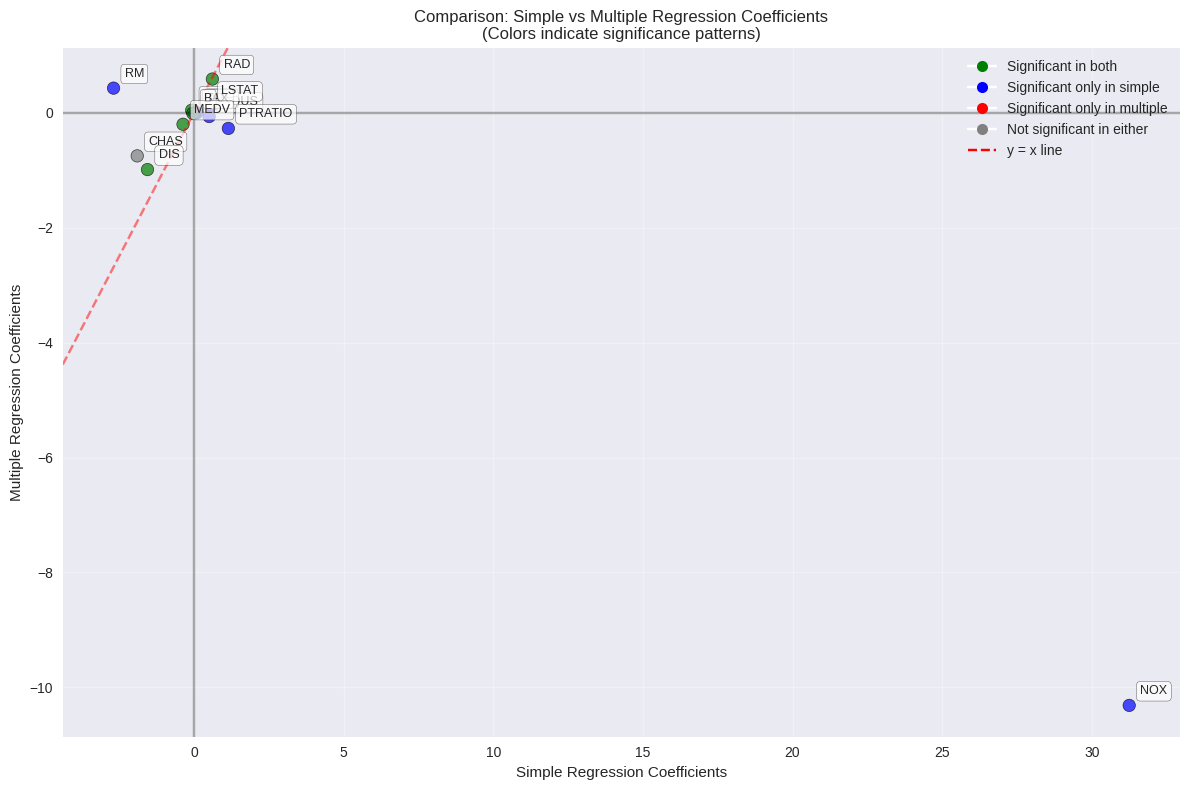


DETAILED COEFFICIENT COMPARISON:
------------------------------------------------------------------------------------------
Predictor  Simple Coef  Multiple Coef   Difference   % Change     Sig Change      Dir Change
------------------------------------------------------------------------------------------
ZN            -0.0739         0.0449      0.1188       160.7% Both significant Different 
INDUS          0.5098        -0.0639     -0.5736      -112.5% Lost significance Different 
CHAS          -1.8928        -0.7491      1.1436        60.4% Neither significant Same      
NOX           31.2485       -10.3135    -41.5621      -133.0% Lost significance Different 
RM            -2.6841         0.4301      3.1142       116.0% Lost significance Different 
AGE            0.1078         0.0015     -0.1063       -98.7% Lost significance Same      
DIS           -1.5509        -0.9872      0.5637        36.3% Both significant Same      
RAD            0.6179         0.5882     -0.0297      

In [23]:
# Part (c): Compare coefficients from simple vs multiple regression
print("\nPART (c): COMPARISON OF SIMPLE VS MULTIPLE REGRESSION COEFFICIENTS")
print("=" * 70)

# Create comparison data
comparison_data = []
for predictor in predictors:
    simple_coef = simple_reg_results[predictor]['coefficient']
    multiple_coef = multiple_model.params[predictor]
    comparison_data.append({
        'predictor': predictor,
        'simple_coef': simple_coef,
        'multiple_coef': multiple_coef,
        'simple_sig': simple_reg_results[predictor]['p_value'] < 0.05,
        'multiple_sig': multiple_model.pvalues[predictor] < 0.05,
        'abs_change': abs(multiple_coef - simple_coef),
        'direction_change': 'Same' if (simple_coef * multiple_coef) > 0 else 'Different'
    })

comparison_df = pd.DataFrame(comparison_data)

# Create the comparison plot
plt.figure(figsize=(12, 8))

# Color points based on significance
colors = []
for _, row in comparison_df.iterrows():
    if row['simple_sig'] and row['multiple_sig']:
        colors.append('green')  # Significant in both
    elif row['simple_sig'] and not row['multiple_sig']:
        colors.append('blue')   # Significant only in simple
    elif not row['simple_sig'] and row['multiple_sig']:
        colors.append('red')    # Significant only in multiple
    else:
        colors.append('gray')   # Not significant in either

# Create scatter plot
plt.scatter(comparison_df['simple_coef'], comparison_df['multiple_coef'],
           c=colors, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add labels for each point
for i, row in comparison_df.iterrows():
    plt.annotate(row['predictor'],
                (row['simple_coef'], row['multiple_coef']),
                xytext=(8, 8), textcoords='offset points', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

# Add reference lines
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.axline((0, 0), slope=1, color='red', linestyle='--', alpha=0.5, label='y = x (no change)')

plt.xlabel('Simple Regression Coefficients')
plt.ylabel('Multiple Regression Coefficients')
plt.title('Comparison: Simple vs Multiple Regression Coefficients\n(Colors indicate significance patterns)')
plt.grid(True, alpha=0.3)

# Create custom legend and place it in top right corner
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Significant in both'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Significant only in simple'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Significant only in multiple'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Not significant in either'),
    Line2D([0], [0], color='red', linestyle='--', label='y = x line')
]

# Place legend in top right corner
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# Detailed comparison table
print("\nDETAILED COEFFICIENT COMPARISON:")
print("-" * 90)
print(f"{'Predictor':<10} {'Simple Coef':<12} {'Multiple Coef':<15} {'Difference':<12} {'% Change':<12} {'Sig Change':<15} {'Dir Change':<10}")
print("-" * 90)

for _, row in comparison_df.iterrows():
    diff = row['multiple_coef'] - row['simple_coef']
    pct_change = (diff / abs(row['simple_coef'])) * 100 if row['simple_coef'] != 0 else np.inf

    sig_change = ""
    if row['simple_sig'] and row['multiple_sig']:
        sig_change = "Both significant"
    elif row['simple_sig'] and not row['multiple_sig']:
        sig_change = "Lost significance"
    elif not row['simple_sig'] and row['multiple_sig']:
        sig_change = "Gained significance"
    else:
        sig_change = "Neither significant"

    print(f"{row['predictor']:<10} {row['simple_coef']:>10.4f} {row['multiple_coef']:>14.4f} {diff:>11.4f} {pct_change:>11.1f}% {sig_change:<15} {row['direction_change']:<10}")

# Summary statistics
print(f"\nSUMMARY OF CHANGES:")
avg_abs_change = comparison_df['abs_change'].mean()
max_abs_change = comparison_df['abs_change'].max()
predictor_max_change = comparison_df.loc[comparison_df['abs_change'].idxmax(), 'predictor']
print(f"Average absolute coefficient change: {avg_abs_change:.4f}")
print(f"Maximum absolute coefficient change: {max_abs_change:.4f} ({predictor_max_change})")
print(f"Predictors that lost significance: {len([p for p in predictors if p in significant_predictors and p not in significant_multiple])}")
print(f"Predictors that gained significance: {len([p for p in predictors if p not in significant_predictors and p in significant_multiple])}")


PART (d): NON-LINEAR ASSOCIATION ANALYSIS


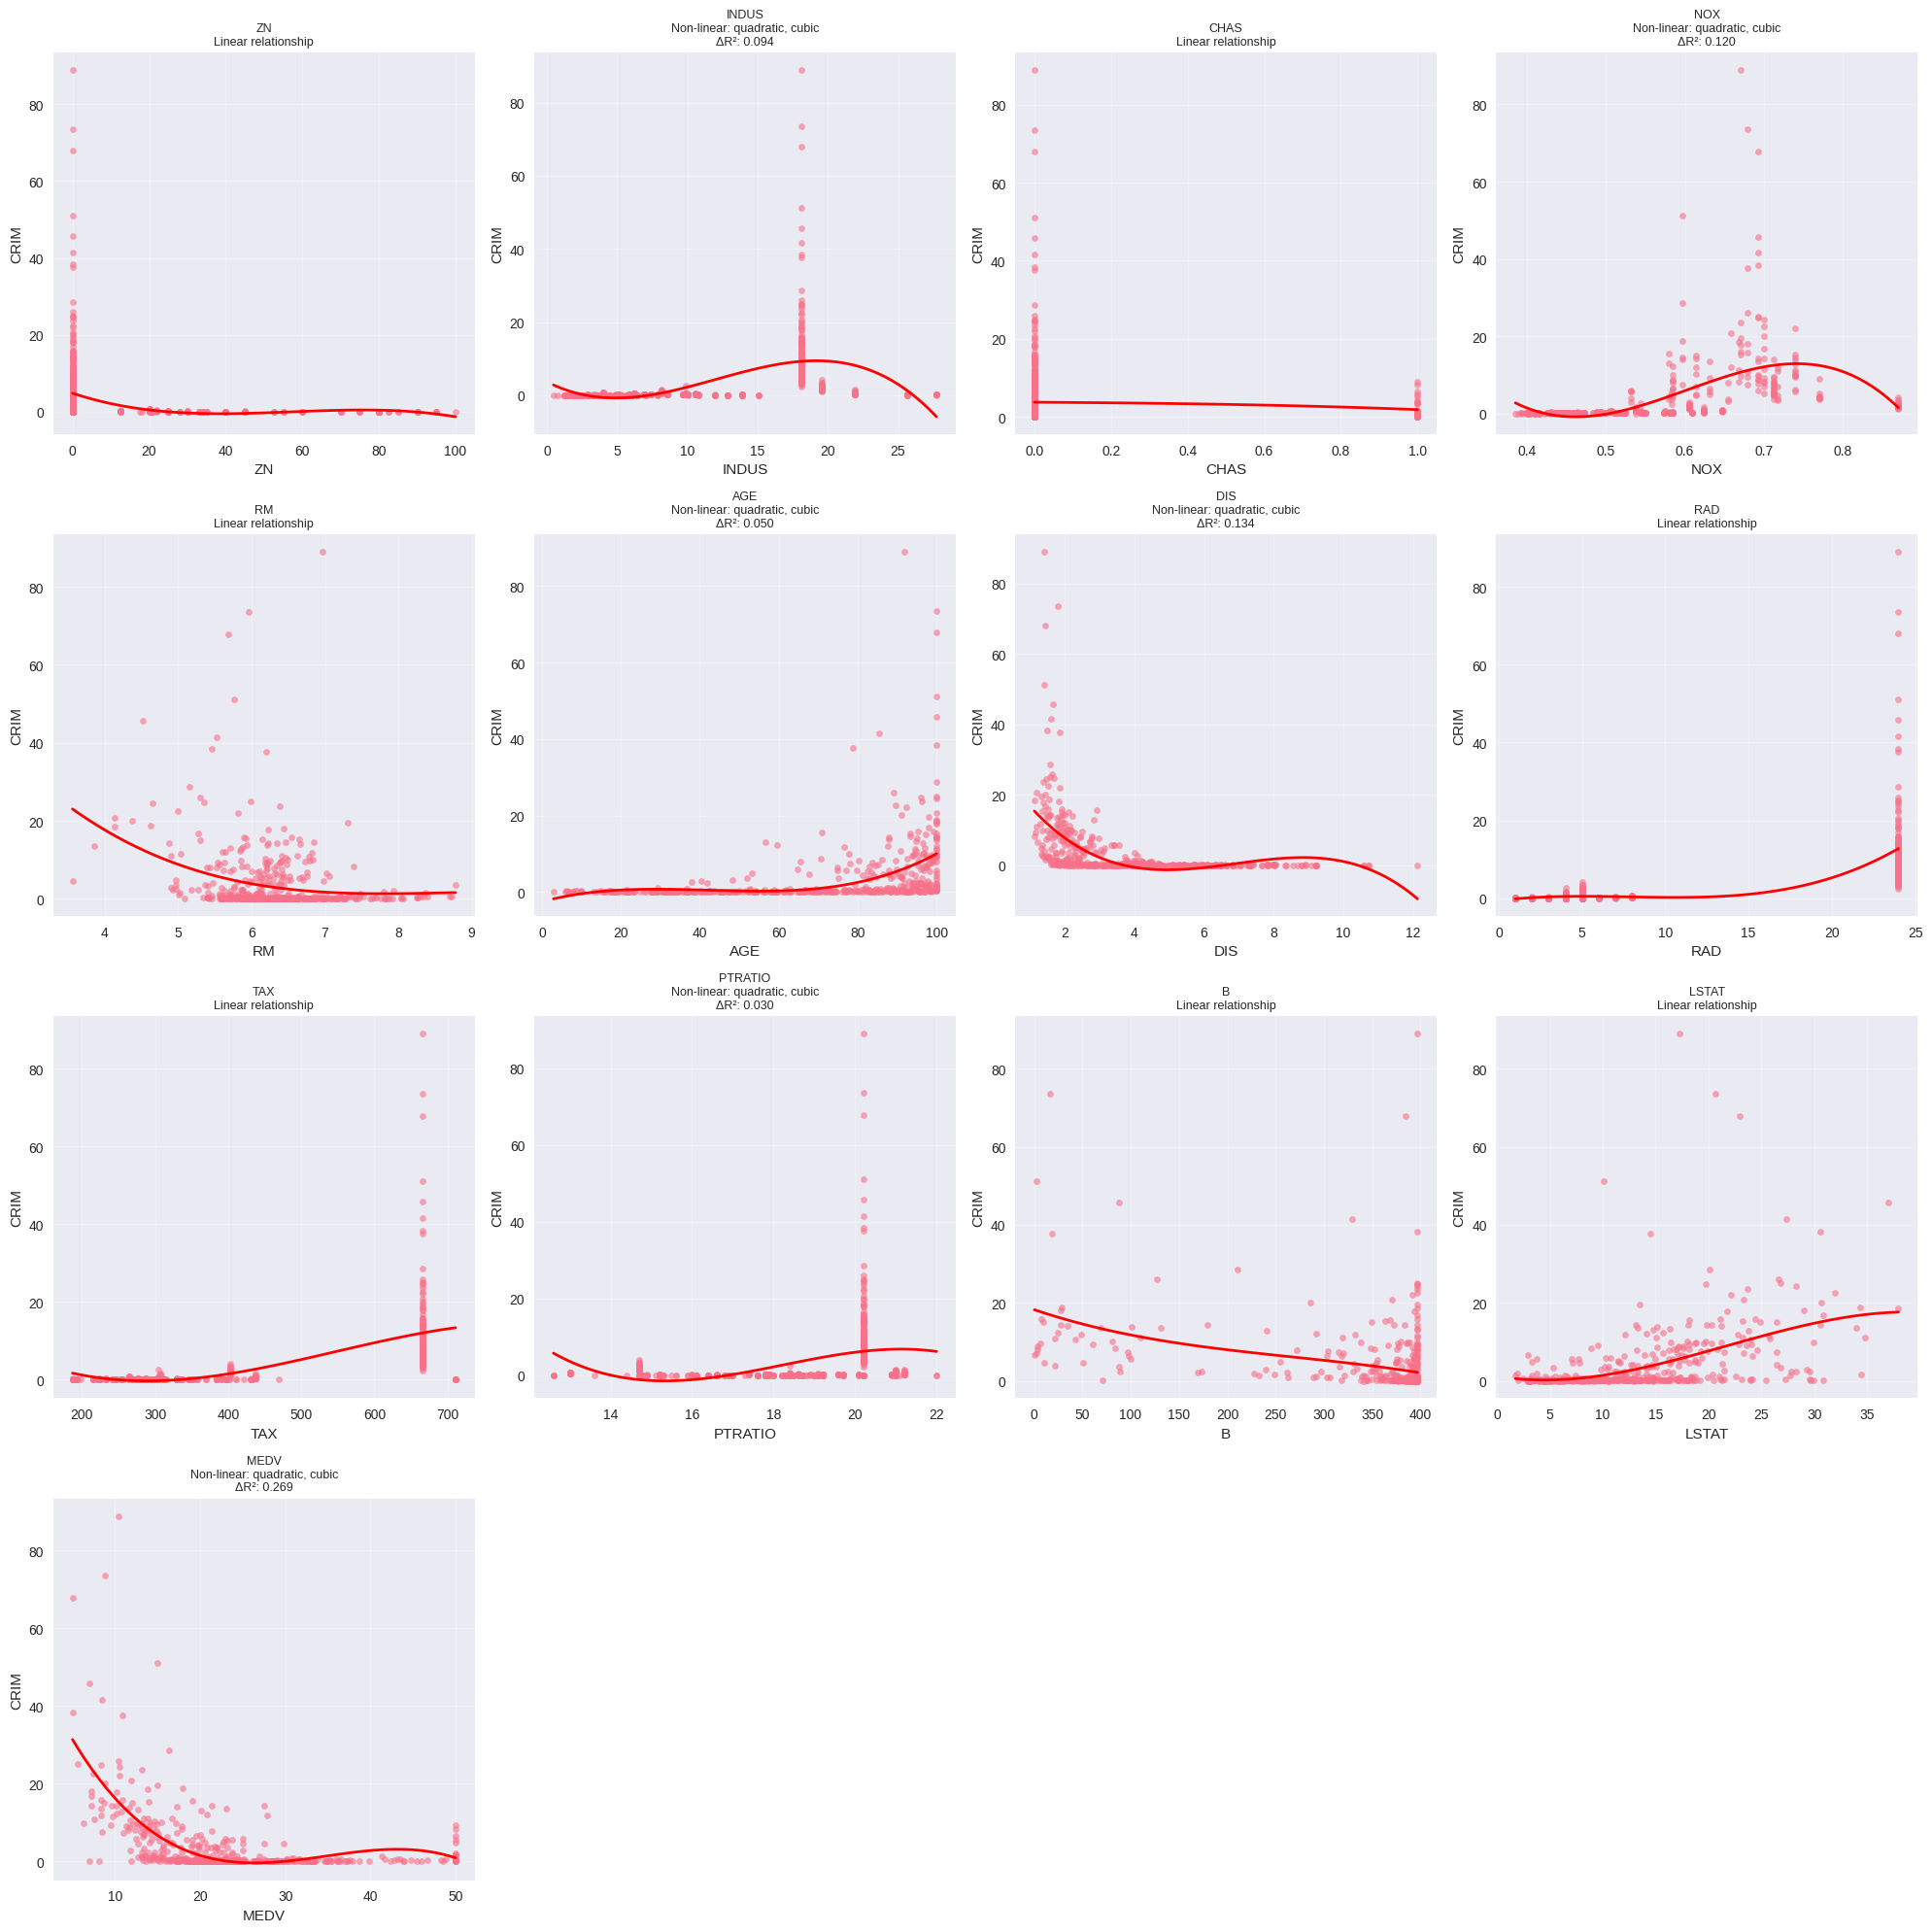


NON-LINEAR ASSOCIATIONS (p < 0.05 for quadratic or cubic terms):
--------------------------------------------------------------------------------
Predictor  Quadratic    Cubic        Linear R²    Poly R²      R² Improvement 
--------------------------------------------------------------------------------
INDUS      ✓            ✓                0.1653      0.2597         0.0943
NOX        ✓            ✓                0.1772      0.2970         0.1198
AGE        ✓            ✓                0.1244      0.1742         0.0498
DIS        ✓            ✓                0.1441      0.2778         0.1337
PTRATIO    ✓            ✓                0.0841      0.1138         0.0297
MEDV       ✓            ✓                0.1508      0.4202         0.2694

Total predictors with non-linear association: 6 out of 13
Predictors with non-linear patterns: ['INDUS', 'NOX', 'AGE', 'DIS', 'PTRATIO', 'MEDV']

DETAILED NON-LINEAR TERM SIGNIFICANCE:
---------------------------------------------------------

In [24]:
# Part (d): Check for non-linear associations
print("\nPART (d): NON-LINEAR ASSOCIATION ANALYSIS")
print("=" * 70)

# Store results for polynomial models
poly_results = {}

# Create subplots for polynomial fits
n_cols = 4
n_rows = (len(predictors) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    # Fit polynomial model: Y = β₀ + β₁X + β₂X² + β₃X³
    X_poly = boston[predictor]
    X_poly_df = pd.DataFrame({
        'x': X_poly,
        'x_sq': X_poly ** 2,
        'x_cube': X_poly ** 3
    })
    X_poly_df = sm.add_constant(X_poly_df)

    y = boston[response_var]
    poly_model = sm.OLS(y, X_poly_df).fit()

    # Store results
    poly_results[predictor] = {
        'model': poly_model,
        'linear_p': poly_model.pvalues['x'],
        'quadratic_p': poly_model.pvalues['x_sq'],
        'cubic_p': poly_model.pvalues['x_cube'],
        'r_squared': poly_model.rsquared,
        'linear_r2': simple_reg_results[predictor]['r_squared']
    }

    # Create plot
    ax = axes[i]

    # Scatter plot
    ax.scatter(boston[predictor], boston[response_var], alpha=0.6, s=20)

    # Polynomial fit curve
    x_range = np.linspace(boston[predictor].min(), boston[predictor].max(), 100)
    X_pred = pd.DataFrame({
        'const': 1,
        'x': x_range,
        'x_sq': x_range ** 2,
        'x_cube': x_range ** 3
    })
    y_pred = poly_model.predict(X_pred)
    ax.plot(x_range, y_pred, color='red', linewidth=2)

    # Add significance information to title
    sig_terms = []
    if poly_model.pvalues['x_sq'] < 0.05:
        sig_terms.append("quadratic")
    if poly_model.pvalues['x_cube'] < 0.05:
        sig_terms.append("cubic")

    r2_improvement = poly_model.rsquared - simple_reg_results[predictor]['r_squared']

    title = f'{predictor}'
    if sig_terms:
        title += f'\nNon-linear: {", ".join(sig_terms)}'
        title += f'\nΔR²: {r2_improvement:.3f}'
    else:
        title += '\nLinear relationship'

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(predictor)
    ax.set_ylabel(response_var)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Summary of non-linear associations
print("\nNON-LINEAR ASSOCIATIONS (p < 0.05 for quadratic or cubic terms):")
print("-" * 80)
print(f"{'Predictor':<10} {'Quadratic':<12} {'Cubic':<12} {'Linear R²':<12} {'Poly R²':<12} {'R² Improvement':<15}")
print("-" * 80)

non_linear_predictors = []
for predictor, results in poly_results.items():
    quadratic_sig = results['quadratic_p'] < 0.05
    cubic_sig = results['cubic_p'] < 0.05

    if quadratic_sig or cubic_sig:
        non_linear_predictors.append(predictor)
        r2_improvement = results['r_squared'] - results['linear_r2']

        quad_symbol = "✓" if quadratic_sig else "✗"
        cubic_symbol = "✓" if cubic_sig else "✗"

        print(f"{predictor:<10} {quad_symbol:<12} {cubic_symbol:<12} {results['linear_r2']:>10.4f} {results['r_squared']:>11.4f} {r2_improvement:>14.4f}")

print(f"\nTotal predictors with non-linear association: {len(non_linear_predictors)} out of {len(predictors)}")
print(f"Predictors with non-linear patterns: {non_linear_predictors}")

# Detailed significance levels for non-linear terms
print("\nDETAILED NON-LINEAR TERM SIGNIFICANCE:")
print("-" * 60)
print(f"{'Predictor':<10} {'Quadratic p-value':<18} {'Cubic p-value':<15}")
print("-" * 60)
for predictor in non_linear_predictors:
    results = poly_results[predictor]
    quad_p = results['quadratic_p']
    cubic_p = results['cubic_p']
    print(f"{predictor:<10} {quad_p:>17.6f} {cubic_p:>14.6f}")